# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

In [3]:
!pip -q install pyverilog networkx matplotlib



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
demo_top = r"""
module chip_top(input clk, input rst_n, output [7:0] gpio_a, output [7:0] gpio_b);
  wire [7:0] A, B, Y_add, Y_xor;
  simple_rom u_rom (.addr(1'b0), .data(A));
  simple_rom u_rom2(.addr(1'b1), .data(B));
  simple_alu u_add (.a(A), .b(B), .op(2'b00), .y(Y_add));
  simple_alu u_xor (.a(A), .b(B), .op(2'b10), .y(Y_xor));
  assign gpio_a = Y_add;
  assign gpio_b = Y_xor;
endmodule
"""

demo_alu = r"""
module simple_alu(input [7:0] a, input [7:0] b, input [1:0] op, output reg [7:0] y);
  always @* begin
    case (op)
      2'b00: y = a + b;
      2'b10: y = a ^ b;
      default: y = a & b;
    endcase
  end
endmodule

module simple_rom(input [0:0] addr, output reg [7:0] data);
  always @* begin
    case (addr)
      1'b0: data = 8'h2A;
      1'b1: data = 8'h11;
      default: data = 8'h00;
    endcase
  end
endmodule
"""

with open("chip_top.v", "w") as f: f.write(demo_top)
with open("blocks.v", "w") as f: f.write(demo_alu)
print("Wrote chip_top.v and blocks.v")


Wrote chip_top.v and blocks.v


In [5]:
import networkx as nx
from pyverilog.vparser.parser import parse
from pyverilog.vparser.ast import (
    ModuleDef, InstanceList, Instance, PortArg,
    Identifier, Pointer, IntConst
)

def _stringify_conn(expr):
    if expr is None:
        return ""
    if isinstance(expr, Identifier):
        return expr.name
    if isinstance(expr, Pointer):     # e.g. data[3]
        base = _stringify_conn(expr.var)
        idx  = _stringify_conn(expr.ptr)
        return f"{base}[{idx}]"
    if isinstance(expr, IntConst):
        return expr.value
    return str(expr)

def _get_portarg_expr(carg):
    # Handle PyVerilog version differences: argname / arg / expr
    if hasattr(carg, "argname") and carg.argname is not None:
        return carg.argname
    if hasattr(carg, "arg") and carg.arg is not None:
        return carg.arg
    if hasattr(carg, "expr") and carg.expr is not None:
        return carg.expr
    return None

def _get_portarg_name(carg, idx):
    # Named .port(...) vs ordered connection
    if getattr(carg, "portname", None) is not None:
        return str(carg.portname)
    return f"_{idx}"

def build_netlist_graph(verilog_files, top=None, treat_top_ios_as_nets=True):
    ast, _ = parse(verilog_files)
    modules = {d.name: d for d in ast.description.definitions if isinstance(d, ModuleDef)}

    if top is None:
        if len(modules) != 1:
            raise ValueError(f"Specify top. Found modules: {list(modules)}")
        top = next(iter(modules))
    if top not in modules:
        raise ValueError(f"Top {top} not found. Available: {list(modules)}")

    top_mod = modules[top]
    G = nx.Graph()

    # Optional: add top I/O names as net nodes
    if treat_top_ios_as_nets and getattr(top_mod, "portlist", None):
        for p in (top_mod.portlist.ports or []):
            name = getattr(p, "name", None) or getattr(getattr(p, "first", None), "name", None)
            if name and not G.has_node(name):
                G.add_node(name, type="net", name=name, is_top_io=True, bipartite=1)

    # One-level instance scan in top module
    for item in getattr(top_mod, "items", []) or []:
        if not isinstance(item, InstanceList):
            continue
        child_mod = item.module
        for inst in item.instances or []:
            if not isinstance(inst, Instance):
                continue
            iname = inst.name
            if not G.has_node(iname):
                G.add_node(iname, type="instance", mod=child_mod, name=iname, bipartite=0, ports={})

            portlist = inst.portlist or []
            for idx, carg in enumerate(portlist):
                if not isinstance(carg, PortArg):
                    continue
                port = _get_portarg_name(carg, idx)
                expr = _get_portarg_expr(carg)
                net  = _stringify_conn(expr)
                if not net:
                    continue
                if not G.has_node(net):
                    G.add_node(net, type="net", name=net, is_top_io=False, bipartite=1)
                G.nodes[iname]["ports"][port] = net
                G.add_edge(iname, net, port=port)
    return G


CWD: c:\Users\abdul\PycharmProjects\JupyterProject
Here: ['FYP.ipynb', 'README.md', 'blocks.v', 'chip_top.v', 'data', 'models', 'parser.out', 'parsetab.py', 'placement_results.json', 'requirements.txt', 'sample.ipynb']
Has chip_top.v: True
Has blocks.v  : True

--- chip_top.v (first 12 lines) ---

module chip_top(input clk, input rst_n, output [7:0] gpio_a, output [7:0] gpio_b);
  wire [7:0] A, B, Y_add, Y_xor;
  simple_rom u_rom (.addr(1'b0), .data(A));
  simple_rom u_rom2(.addr(1'b1), .data(B));
  simple_alu u_add (.a(A), .b(B), .op(2'b00), .y(Y_add));
  simple_alu u_xor (.a(A), .b(B), .op(2'b10), .y(Y_xor));
  assign gpio_a = Y_add;
  assign gpio_b = Y_xor;
endmodule

--- blocks.v (first 12 lines) ---

module simple_alu(input [7:0] a, input [7:0] b, input [1:0] op, output reg [7:0] y);
  always @* begin
    case (op)
      2'b00: y = a + b;
      2'b10: y = a ^ b;
      default: y = a & b;
    endcase
  end
endmodule

module simple_rom(input [0:0] addr, output reg [7:0] data);


Generating LALR tables


Modules found: ['chip_top', 'simple_alu', 'simple_rom']
Instances: 4
Nets     : 12
Edges    : 12


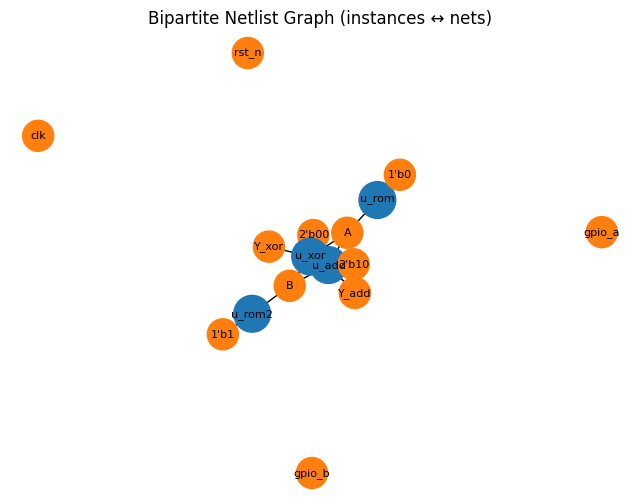

In [6]:
# --- DIAGNOSTIC + BUILD + PLOT (PyVerilog) ---
import os, glob, json, sys, traceback
import networkx as nx
import matplotlib.pyplot as plt

print("CWD:", os.getcwd())
print("Here:", sorted(glob.glob("*")))
print("Has chip_top.v:", os.path.exists("chip_top.v"))
print("Has blocks.v  :", os.path.exists("blocks.v"))

# 1) Show first few lines (sanity)
def head(path, n=12):
    if os.path.exists(path):
        with open(path, "r") as f:
            print(f"\n--- {path} (first {n} lines) ---")
            for i, line in enumerate(f):
                if i >= n: break
                print(line.rstrip())
    else:
        print(f"\n!! Missing file: {path}")

head("chip_top.v")
head("blocks.v")

# 2) Robust parser (handles PortArg .arg/.argname/.expr)
from pyverilog.vparser.parser import parse
from pyverilog.vparser.ast import (
    ModuleDef, InstanceList, Instance, PortArg,
    Identifier, Pointer, IntConst
)

def _stringify_conn(expr):
    if expr is None: return ""
    if isinstance(expr, Identifier): return expr.name
    if isinstance(expr, Pointer):
        base = _stringify_conn(expr.var)
        idx  = _stringify_conn(expr.ptr)
        return f"{base}[{idx}]"
    if isinstance(expr, IntConst): return expr.value
    return str(expr)

def _get_portarg_expr(carg):
    for attr in ("argname","arg","expr"):
        if hasattr(carg, attr) and getattr(carg, attr) is not None:
            return getattr(carg, attr)
    return None

def _get_portarg_name(carg, idx):
    return str(carg.portname) if getattr(carg, "portname", None) is not None else f"_{idx}"

def build_netlist_graph(verilog_files, top=None, treat_top_ios_as_nets=True):
    ast, directives = parse(verilog_files)
    modules = {d.name: d for d in ast.description.definitions if isinstance(d, ModuleDef)}
    print("Modules found:", list(modules.keys()))
    if top is None:
        if len(modules) != 1:
            raise ValueError(f"Specify top. Found modules: {list(modules)}")
        top = next(iter(modules))
    if top not in modules:
        raise ValueError(f"Top {top} not in modules: {list(modules)}")

    top_mod = modules[top]
    G = nx.Graph()

    # add top IOs as nets
    if treat_top_ios_as_nets and getattr(top_mod, "portlist", None):
        for p in (top_mod.portlist.ports or []):
            name = getattr(p, "name", None) or getattr(getattr(p, "first", None), "name", None)
            if name and not G.has_node(name):
                G.add_node(name, type="net", name=name, is_top_io=True, bipartite=1)

    # scan instances (one level)
    for item in getattr(top_mod, "items", []) or []:
        if not isinstance(item, InstanceList): continue
        child_mod = item.module
        for inst in item.instances or []:
            if not isinstance(inst, Instance): continue
            iname = inst.name
            if not G.has_node(iname):
                G.add_node(iname, type="instance", mod=child_mod, name=iname, bipartite=0, ports={})
            for idx, carg in enumerate(inst.portlist or []):
                if not isinstance(carg, PortArg): continue
                port = _get_portarg_name(carg, idx)
                expr = _get_portarg_expr(carg)
                net  = _stringify_conn(expr)
                if not net: continue
                if not G.has_node(net):
                    G.add_node(net, type="net", name=net, is_top_io=False, bipartite=1)
                G.nodes[iname]["ports"][port] = net
                G.add_edge(iname, net, port=port)

    return G

# 3) Build
try:
    G = build_netlist_graph(["chip_top.v", "blocks.v"], top="chip_top")
    print("Instances:", sum(1 for _, d in G.nodes(data=True) if d["type"]=="instance"))
    print("Nets     :", sum(1 for _, d in G.nodes(data=True) if d["type"]=="net"))
    print("Edges    :", G.number_of_edges())

    # 4) Plot
    pos = nx.spring_layout(G, seed=7)
    colors = ["tab:blue" if d["type"]=="instance" else "tab:orange" for _,d in G.nodes(data=True)]
    sizes  = [700 if d["type"]=="instance" else 500 for _,d in G.nodes(data=True)]
    plt.figure(figsize=(8,6))
    nx.draw_networkx(G, pos=pos, node_color=colors, node_size=sizes, with_labels=True, font_size=8)
    plt.axis("off"); plt.title("Bipartite Netlist Graph (instances ↔ nets)")
    plt.show()

except Exception as e:
    print("\nPyVerilog path failed:")
    traceback.print_exc()
    print("\nIf this persists, use Option B (pure-Python hdlConvertor) below.")


In [7]:
# Use the in-memory graph G if you have it; else load the JSON we saved earlier.
import json, os, networkx as nx

if "G" in globals():
    G_src = G
else:
    with open("netlist_demo.json") as f:
        data = json.load(f)
    G_src = nx.Graph()
    for inst in data["instances"]:
        G_src.add_node(inst["name"], type="instance", mod=inst["mod"], ports=inst["ports"])
    for net in data["nets"]:
        G_src.add_node(net["name"], type="net")
    for e in data["edges"]:
        G_src.add_edge(e["instance"], e["net"], port=e["port"])

instances = [n for n,d in G_src.nodes(data=True) if d.get("type")=="instance"]
nets      = [n for n,d in G_src.nodes(data=True) if d.get("type")=="net"]
print("Instances:", instances)
print("Nets     :", nets)


Instances: ['u_rom', 'u_rom2', 'u_add', 'u_xor']
Nets     : ['clk', 'rst_n', 'gpio_a', 'gpio_b', "1'b0", 'A', "1'b1", 'B', "2'b00", 'Y_add', "2'b10", 'Y_xor']


In [8]:
import numpy as np
rng = np.random.default_rng(7)

# Grid size (keep small for now)
H, W = 24, 24   # rows (y), cols (x)

# Assign simple macro sizes (in grid cells) — tweak as you like
# Here: ALUs are 4x3, ROMs 5x4, others 3xA3 default
sizes = {}
for inst in instances:
    mod = G_src.nodes[inst].get("mod","").lower()
    if "alu" in mod:
        sizes[inst] = (4,3)
    elif "rom" in mod or "sram" in mod:
        sizes[inst] = (5,4)
    else:
        sizes[inst] = (3,3)

# Occupancy grid (0=free, 1=occupied)
occ = np.zeros((H, W), dtype=np.uint8)

def fits(y, x, h, w):
    if y<0 or x<0 or y+h>H or x+w>W:
        return False
    return np.all(occ[y:y+h, x:x+w] == 0)

def place_rect(y, x, h, w):
    occ[y:y+h, x:x+w] = 1

# Simple legal random placement (retry a few times for each inst)
placements = {}  # inst -> (y, x, h, w) top-left on grid
for inst in instances:
    h, w = sizes[inst]
    placed = False
    for _ in range(2000):
        y = int(rng.integers(0, H-h))
        x = int(rng.integers(0, W-w))
        if fits(y, x, h, w):
            place_rect(y, x, h, w)
            placements[inst] = (y, x, h, w)
            placed = True
            break
    if not placed:
        raise RuntimeError(f"Could not place {inst}; try smaller sizes or a larger grid.")

print("Placed:", placements)


Placed: {'u_rom': (17, 12, 5, 4), 'u_rom2': (12, 17, 5, 4), 'u_add': (16, 4, 4, 3), 'u_xor': (1, 6, 4, 3)}


In [9]:
%pip install scipy


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
# Build net -> list of instance centers it touches (ignore top IO-only nets for now)
def rect_center(y,x,h,w):
    return (y + h/2.0, x + w/2.0)

net_to_points = {}
for net in nets:
    pts = []
    # neighbors of net are instances (bipartite)
    for nbr in G_src.neighbors(net):
        if G_src.nodes[nbr].get("type")=="instance" and nbr in placements:
            y,x,h,w = placements[nbr]
            pts.append(rect_center(y,x,h,w))
    if len(pts) >= 1:
        net_to_points[net] = pts

# HPWL
def hpwl_for_net(points):
    ys = [p[0] for p in points]
    xs = [p[1] for p in points]
    return (max(xs)-min(xs)) + (max(ys)-min(ys))

hpwl_total = sum(hpwl_for_net(pts) for pts in net_to_points.values() if len(pts)>=2)
print(f"HPWL ≈ {hpwl_total:.2f}")

# Very simple L-shaped routing congestion (just for a feel)
cong = np.zeros_like(occ, dtype=np.int32)
for pts in net_to_points.values():
    if len(pts) < 2:
        continue
    # connect each point to the first one with an L route
    y0,x0 = pts[0]
    y0,x0 = int(round(y0)), int(round(x0))
    for (y1,x1) in pts[1:]:
        y1,x1 = int(round(y1)), int(round(x1))
        # horizontal then vertical
        xlo, xhi = sorted([x0,x1])
        ylo, yhi = sorted([y0,y1])
        cong[y0, xlo:xhi+1] += 1
        cong[ylo:yhi+1, x1] += 1

# Smooth (5x1 + 1x5)
from scipy.ndimage import convolve1d
cong_s = convolve1d(cong, np.ones(5)/5.0, axis=0, mode="nearest")
cong_s = convolve1d(cong_s, np.ones(5)/5.0, axis=1, mode="nearest")

# Congestion score = mean of top 10%
flat = cong_s.flatten()
k = max(1, int(0.10*flat.size))
cong_score = float(np.mean(np.sort(flat)[-k:]))
print(f"Congestion (top10%) ≈ {cong_score:.3f}")


HPWL ≈ 53.50
Congestion (top10%) ≈ 0.000


In [11]:
# Build net -> list of instance centers it touches (ignore top IO-only nets for now)
def rect_center(y,x,h,w):
    return (y + h/2.0, x + w/2.0)

net_to_points = {}
for net in nets:
    pts = []
    # neighbors of net are instances (bipartite)
    for nbr in G_src.neighbors(net):
        if G_src.nodes[nbr].get("type")=="instance" and nbr in placements:
            y,x,h,w = placements[nbr]
            pts.append(rect_center(y,x,h,w))
    if len(pts) >= 1:
        net_to_points[net] = pts

# HPWL
def hpwl_for_net(points):
    ys = [p[0] for p in points]
    xs = [p[1] for p in points]
    return (max(xs)-min(xs)) + (max(ys)-min(ys))

hpwl_total = sum(hpwl_for_net(pts) for pts in net_to_points.values() if len(pts)>=2)
print(f"HPWL ≈ {hpwl_total:.2f}")

# Very simple L-shaped routing congestion (just for a feel)
cong = np.zeros_like(occ, dtype=np.int32)
for pts in net_to_points.values():
    if len(pts) < 2:
        continue
    # connect each point to the first one with an L route
    y0,x0 = pts[0]
    y0,x0 = int(round(y0)), int(round(x0))
    for (y1,x1) in pts[1:]:
        y1,x1 = int(round(y1)), int(round(x1))
        # horizontal then vertical
        xlo, xhi = sorted([x0,x1])
        ylo, yhi = sorted([y0,y1])
        cong[y0, xlo:xhi+1] += 1
        cong[ylo:yhi+1, x1] += 1

# Smooth (5x1 + 1x5)
from scipy.ndimage import convolve1d
cong_s = convolve1d(cong, np.ones(5)/5.0, axis=0, mode="nearest")
cong_s = convolve1d(cong_s, np.ones(5)/5.0, axis=1, mode="nearest")

# Congestion score = mean of top 10%
flat = cong_s.flatten()
k = max(1, int(0.10*flat.size))
cong_score = float(np.mean(np.sort(flat)[-k:]))
print(f"Congestion (top10%) ≈ {cong_score:.3f}")


HPWL ≈ 53.50
Congestion (top10%) ≈ 0.000


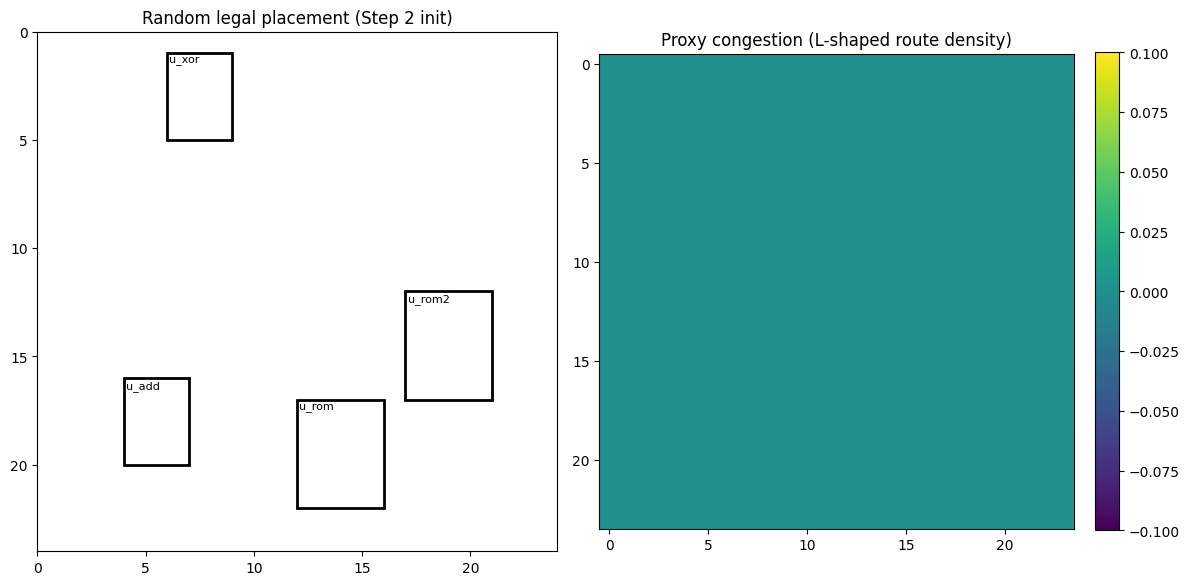

In [12]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(1,2, figsize=(12,6))

# Left: placement
ax[0].imshow(np.zeros_like(occ), cmap="gray_r", vmin=0, vmax=1)
for inst,(y,x,h,w) in placements.items():
    ax[0].add_patch(Rectangle((x,y), w,h, fill=False, lw=2))
    ax[0].text(x+0.1, y+0.1, inst, fontsize=8, ha="left", va="top")
ax[0].set_xlim(0,W); ax[0].set_ylim(H,0)
ax[0].set_title("Random legal placement (Step 2 init)")

# Right: congestion
im = ax[1].imshow(cong_s, origin="upper")
ax[1].set_title("Proxy congestion (L-shaped route density)")
fig.colorbar(im, ax=ax[1], fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()


In [13]:
import numpy as np

# Helper maps
inst_to_nets = {i: [] for i in instances}
for net in nets:
    for nbr in G_src.neighbors(net):
        if G_src.nodes[nbr].get("type") == "instance":
            inst_to_nets[nbr].append(net)

# Reusable utils
def rect_center(y,x,h,w): return (y + h/2.0, x + w/2.0)

def hpwl_points(points):
    if len(points) < 2: return 0.0
    ys = [p[0] for p in points]; xs = [p[1] for p in points]
    return (max(xs) - min(xs)) + (max(ys) - min(ys))

def hpwl_total_from_placements(plc):
    # compute HPWL over all nets using placed instances only
    total = 0.0
    for net in nets:
        pts = []
        for nbr in G_src.neighbors(net):
            if G_src.nodes[nbr].get("type") == "instance" and nbr in plc:
                y,x,h,w = plc[nbr]
                pts.append(rect_center(y,x,h,w))
        total += hpwl_points(pts)
    return total

# Fresh empty occupancy & placements
occ_g = np.zeros((H, W), dtype=np.uint8)
placements_greedy = {}

def fits(y, x, h, w):
    if y<0 or x<0 or y+h>H or x+w>W: return False
    return np.all(occ_g[y:y+h, x:x+w] == 0)

def place_rect(y, x, h, w): occ_g[y:y+h, x:x+w] = 1

# Order: bigger & more connected first
order = sorted(instances, key=lambda i: (sizes[i][0]*sizes[i][1], len(inst_to_nets[i])), reverse=True)

# Candidate sampling step to keep it fast (try every Kth grid cell)
K = 2  # smaller K = denser search, slower but better
best_hpwl_running = 0.0

for inst in order:
    h, w = sizes[inst]
    best = None
    # Search candidate cells
    for y in range(0, H-h+1, K):
        for x in range(0, W-w+1, K):
            if not fits(y, x, h, w):
                continue
            # Tentative placement
            tmp = dict(placements_greedy)
            tmp[inst] = (y, x, h, w)
            # Compute incremental HPWL only on nets touching 'inst'
            inc = 0.0
            for net in inst_to_nets[inst]:
                pts = []
                for nbr in G_src.neighbors(net):
                    if G_src.nodes[nbr].get("type")!="instance":
                        continue
                    if nbr == inst:
                        pts.append(rect_center(y, x, h, w))
                    elif nbr in placements_greedy:
                        y2,x2,h2,w2 = placements_greedy[nbr]
                        pts.append(rect_center(y2,x2,h2,w2))
                inc += hpwl_points(pts)
            # Track best
            if best is None or inc < best[0]:
                best = (inc, y, x)
    if best is None:
        raise RuntimeError(f"Could not place {inst} greedily; enlarge grid or lower sizes.")
    _, yb, xb = best
    place_rect(yb, xb, h, w)
    placements_greedy[inst] = (yb, xb, h, w)

hpwl_greedy = hpwl_total_from_placements(placements_greedy)
print("Greedy HPWL ≈", round(hpwl_greedy, 3))


Greedy HPWL ≈ 19.0


Random   -> HPWL: 53.50 | Cong(top10%): 1.404
Greedy   -> HPWL: 19.00 | Cong(top10%): 0.702


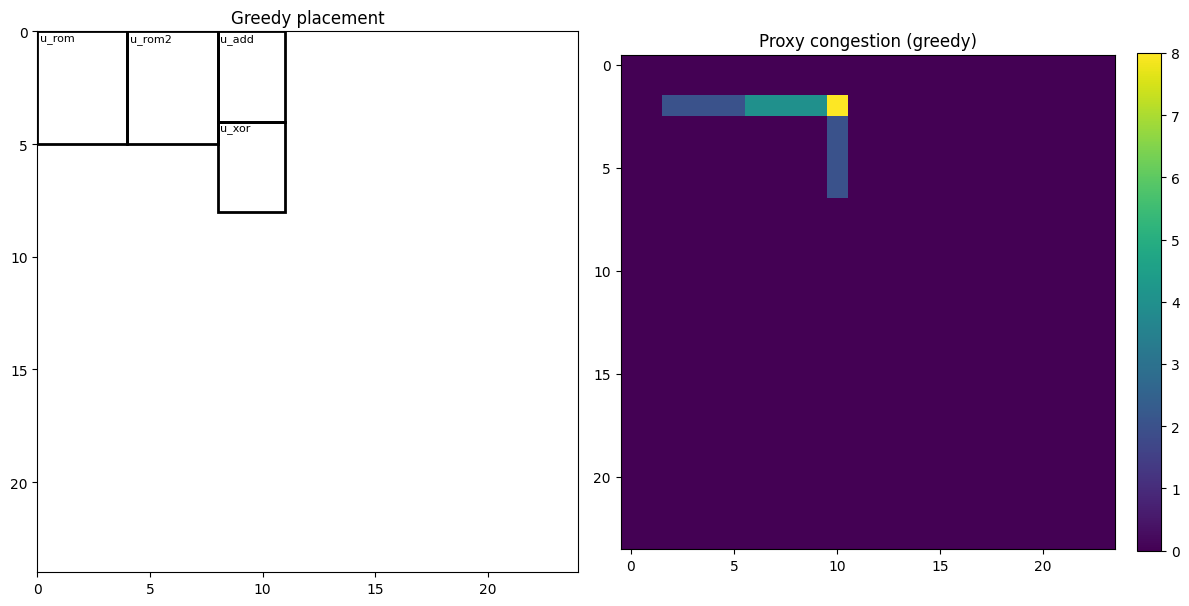

In [14]:
# Recompute random metrics using previous 'placements' (from Cell B/C)
def compute_congestion(plc):
    cong = np.zeros((H, W), dtype=np.int32)
    # net -> points
    def center_for(i):
        y,x,h,w = plc[i]
        return (int(round(y + h/2.0)), int(round(x + w/2.0)))
    for net in nets:
        pts = []
        for nbr in G_src.neighbors(net):
            if G_src.nodes[nbr].get("type")=="instance" and nbr in plc:
                pts.append(center_for(nbr))
        if len(pts) < 2:
            continue
        y0,x0 = pts[0]
        for (y1,x1) in pts[1:]:
            xlo,xhi = sorted([x0,x1]); ylo,yhi = sorted([y0,y1])
            cong[y0, xlo:xhi+1] += 1
            cong[ylo:yhi+1, x1] += 1
    return cong.astype(float)

def cong_score_from(cong_map):
    flat = cong_map.flatten()
    k = max(1, int(0.10 * flat.size))
    return float(np.mean(np.sort(flat)[-k:]))

# Random (from earlier)
cong_r = compute_congestion(placements)
score_r = cong_score_from(cong_r)
hpwl_r = hpwl_total_from_placements(placements)

# Greedy
cong_g = compute_congestion(placements_greedy)
score_g = cong_score_from(cong_g)

print(f"Random   -> HPWL: {hpwl_r:.2f} | Cong(top10%): {score_r:.3f}")
print(f"Greedy   -> HPWL: {hpwl_greedy:.2f} | Cong(top10%): {score_g:.3f}")

# Plot greedy placement + congestion
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(1,2, figsize=(12,6))

# Greedy placement
ax[0].imshow(np.zeros((H,W)), cmap="gray_r", vmin=0, vmax=1)
for inst,(y,x,h,w) in placements_greedy.items():
    ax[0].add_patch(Rectangle((x,y), w,h, fill=False, lw=2))
    ax[0].text(x+0.1, y+0.1, inst, fontsize=8, ha="left", va="top")
ax[0].set_xlim(0,W); ax[0].set_ylim(H,0)
ax[0].set_title("Greedy placement")

# Greedy congestion
im = ax[1].imshow(cong_g, origin="upper")
ax[1].set_title("Proxy congestion (greedy)")
fig.colorbar(im, ax=ax[1], fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()


In [15]:
import json, time
out = {
    "grid": {"H": H, "W": W},
    "sizes": sizes,
    "placements_random": placements,
    "placements_greedy": placements_greedy,
    "metrics": {
        "random": {"hpwl": float(hpwl_r), "congestion_top10": float(score_r)},
        "greedy": {"hpwl": float(hpwl_greedy), "congestion_top10": float(score_g)},
    },
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S")
}
with open("placement_results.json", "w") as f:
    json.dump(out, f, indent=2)
print("Saved: placement_results.json")


Saved: placement_results.json


In [16]:
%pip install gymnasium sb3-contrib stable-baselines3 torch --upgrade


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np

def rect_center(y,x,h,w): return (y + h/2.0, x + w/2.0)

def hpwl_points(points):
    if len(points) < 2: return 0.0
    ys = [p[0] for p in points]; xs = [p[1] for p in points]
    return (max(xs)-min(xs)) + (max(ys)-min(ys))

def hpwl_total_from_placements(plc, nets, G_src):
    total = 0.0
    for net in nets:
        pts = []
        for nbr in G_src.neighbors(net):
            if G_src.nodes[nbr].get("type")=="instance" and nbr in plc:
                y,x,h,w = plc[nbr]
                pts.append(rect_center(y,x,h,w))
        total += hpwl_points(pts)
    return total

def compute_congestion(plc, H, W, nets, G_src):
    cong = np.zeros((H, W), dtype=np.int32)
    def center_for(i):
        y,x,h,w = plc[i]
        return (int(round(y + h/2.0)), int(round(x + w/2.0)))
    for net in nets:
        pts = []
        for nbr in G_src.neighbors(net):
            if G_src.nodes[nbr].get("type")=="instance" and nbr in plc:
                pts.append(center_for(nbr))
        if len(pts) < 2: continue
        y0,x0 = pts[0]
        for (y1,x1) in pts[1:]:
            xlo,xhi = sorted([x0,x1]); ylo,yhi = sorted([y0,y1])
            cong[y0, xlo:xhi+1] += 1
            cong[ylo:yhi+1, x1] += 1
    return cong.astype(float)

def congestion_score(cong_map):
    flat = cong_map.flatten()
    k = max(1, int(0.10 * flat.size))
    return float(np.mean(np.sort(flat)[-k:]))

class PlacementEnv(gym.Env):
    """
    Observation: Dict(
      canvas: (H,W) occupancy 0/1,
      cur: (4,) [h, w, norm_deg, idx_norm],
      mask: (H*W,) bool legal-action mask  (returned via .info for MaskablePPO)
    )
    Action: Discrete(H*W) -> place current instance's top-left at (y,x).
    Reward: 0 until terminal; at the end: -(HPWL + λ * congestion).
    """
    metadata = {"render_modes": []}

    def __init__(self, instances, nets, sizes, G_src, H=24, W=24, lam_cong=0.01, seed=7):
        super().__init__()
        self.instances = list(instances)
        # Order bigger & more connected first (helps learning)
        deg = {i: sum(1 for _ in G_src.neighbors(i) if G_src.nodes[_].get("type")=="net") for i in self.instances}
        self.order = sorted(self.instances, key=lambda i: (sizes[i][0]*sizes[i][1], deg[i]), reverse=True)
        self.nets = list(nets)
        self.sizes = dict(sizes)
        self.G_src = G_src
        self.H, self.W = H, W
        self.lam = lam_cong
        self.rng = np.random.default_rng(seed)

        self.action_space = spaces.Discrete(self.H * self.W)
        self.observation_space = spaces.Dict({
            "canvas": spaces.Box(0, 1, shape=(self.H, self.W), dtype=np.uint8),
            "cur":    spaces.Box(low=0.0, high=1.0, shape=(4,), dtype=np.float32),
        })

        # precompute degrees
        self.deg = deg
        self.reset(seed=seed)

    def _fits(self, y, x, h, w):
        if y<0 or x<0 or y+h>self.H or x+w>self.W: return False
        return np.all(self.occ[y:y+h, x:x+w] == 0)

    def _mask(self):
        """Boolean mask over flattened grid; True = legal."""
        mask = np.zeros(self.H*self.W, dtype=bool)
        if self.idx >= len(self.order):  # terminal
            return mask
        inst = self.order[self.idx]
        h, w = self.sizes[inst]
        for y in range(self.H - h + 1):
            row = y * self.W
            for x in range(self.W - w + 1):
                if self._fits(y, x, h, w):
                    mask[row + x] = True
        return mask

    def _obs(self):
        # normalize degree by max degree in this netlist
        maxd = max(1, max(self.deg.values()))
        if self.idx < len(self.order):
            inst = self.order[self.idx]
            h, w = self.sizes[inst]
            cur = np.array([h/self.H, w/self.W, self.deg[inst]/maxd, self.idx/max(1,len(self.order)-1)], dtype=np.float32)
        else:
            cur = np.zeros(4, dtype=np.float32)
        return {"canvas": self.occ.copy(), "cur": cur}

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.occ = np.zeros((self.H, self.W), dtype=np.uint8)
        self.idx = 0
        self.placements = {}  # inst -> (y,x,h,w)
        obs = self._obs()
        info = {"action_mask": self._mask()}
        return obs, info

    def step(self, action):
        assert self.action_space.contains(action)
        done = False
        reward = 0.0

        # current inst
        if self.idx >= len(self.order):
            # Already terminal
            return self._obs(), 0.0, True, False, {"action_mask": self._mask()}

        inst = self.order[self.idx]
        h, w = self.sizes[inst]
        y, x = divmod(action, self.W)

        # illegal action: give small penalty and continue (maskable PPO should avoid these)
        if not self._fits(y, x, h, w):
            obs = self._obs()
            info = {"action_mask": self._mask(), "illegal": True}
            return obs, -0.05, False, False, info

        # place
        self.occ[y:y+h, x:x+w] = 1
        self.placements[inst] = (y, x, h, w)
        self.idx += 1

        # terminal?
        if self.idx >= len(self.order):
            hpwl = hpwl_total_from_placements(self.placements, self.nets, self.G_src)
            cong = compute_congestion(self.placements, self.H, self.W, self.nets, self.G_src)
            ctop = congestion_score(cong)
            reward = -(hpwl + self.lam * ctop)
            done = True

        obs = self._obs()
        info = {"action_mask": self._mask()}
        return obs, reward, done, False, info


In [18]:
env = PlacementEnv(instances, nets, sizes, G_src, H=24, W=24, lam_cong=0.01)
obs, info = env.reset()
total = 0.0
for t in range(len(instances)):
    mask = info["action_mask"]
    legal = np.flatnonzero(mask)
    a = int(np.random.choice(legal)) if len(legal) else 0
    obs, r, done, trunc, info = env.step(a)
    total += r
    if done: break
print("Random episode return:", total)


Random episode return: -51.51754385964912


In [19]:
from sb3_contrib import MaskablePPO
from sb3_contrib.common.wrappers import ActionMasker
from stable_baselines3.common.vec_env import DummyVecEnv

def mask_fn(env):
    # sb3-contrib expects mask as 1D bool array
    return env._mask()

# Single-env vector wrapper
def make_env():
    return ActionMasker(PlacementEnv(instances, nets, sizes, G_src, H=24, W=24, lam_cong=0.01), mask_fn)

venv = DummyVecEnv([make_env])

model = MaskablePPO("MultiInputPolicy", venv, verbose=0, n_steps=256, batch_size=256, learning_rate=3e-4, gamma=0.995)
model.learn(total_timesteps=5000)  # keep small for a smoke test

# Evaluate one episode
env_eval = PlacementEnv(instances, nets, sizes, G_src, H=24, W=24, lam_cong=0.01)
obs, info = env_eval.reset()
ep_ret = 0.0
while True:
    mask = info["action_mask"]
    action, _ = model.predict(obs, action_masks=mask, deterministic=True)
    obs, r, done, trunc, info = env_eval.step(int(action))
    ep_ret += r
    if done: break
print("PPO episode return:", ep_ret)


PPO episode return: -29.009473684210526


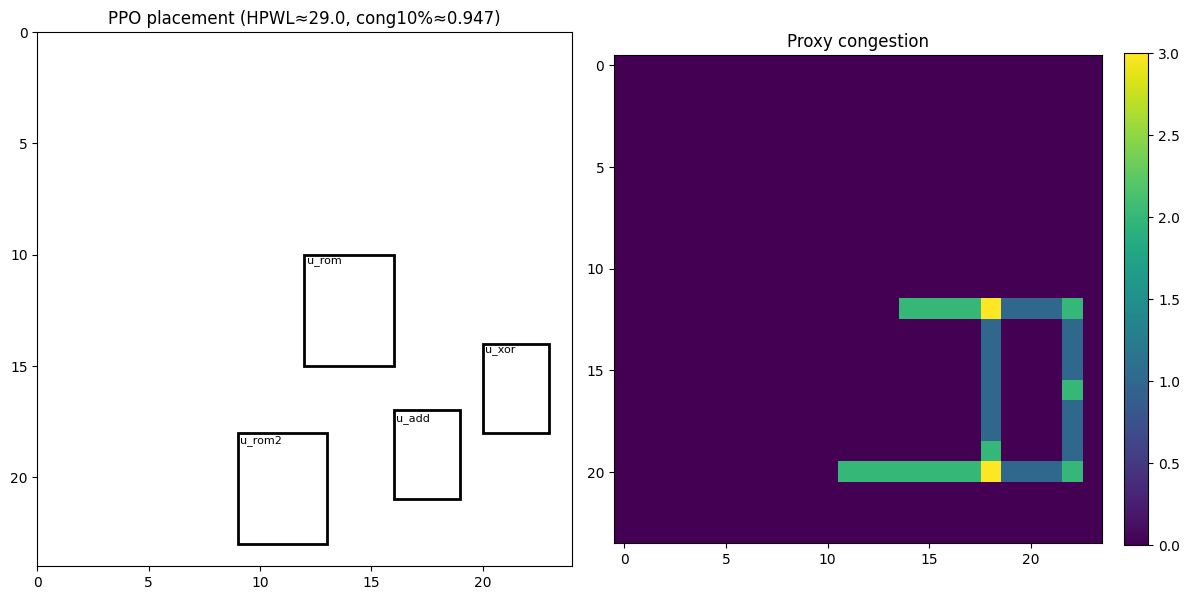

In [20]:
# Rebuild the final placement using the trained model
env_vis = PlacementEnv(instances, nets, sizes, G_src, H=24, W=24, lam_cong=0.01)
obs, info = env_vis.reset()
while True:
    mask = info["action_mask"]
    action, _ = model.predict(obs, action_masks=mask, deterministic=True)
    obs, r, done, trunc, info = env_vis.step(int(action))
    if done: break

# Plot
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

plc = env_vis.placements
cong = compute_congestion(plc, env_vis.H, env_vis.W, nets, G_src)
hpwl = hpwl_total_from_placements(plc, nets, G_src)
ctop = congestion_score(cong)

fig, ax = plt.subplots(1,2, figsize=(12,6))
ax[0].imshow(np.zeros((env_vis.H, env_vis.W)), cmap="gray_r", vmin=0, vmax=1)
for inst,(y,x,h,w) in plc.items():
    ax[0].add_patch(Rectangle((x,y), w,h, fill=False, lw=2))
    ax[0].text(x+0.1, y+0.1, inst, fontsize=8, ha="left", va="top")
ax[0].set_xlim(0, env_vis.W); ax[0].set_ylim(env_vis.H, 0)
ax[0].set_title(f"PPO placement (HPWL≈{hpwl:.1f}, cong10%≈{ctop:.3f})")

im = ax[1].imshow(cong, origin="upper")
ax[1].set_title("Proxy congestion")
fig.colorbar(im, ax=ax[1], fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()


In [21]:
import os

def export_to_plc(placements, out_path="placement.plc"):
    with open(out_path, "w") as f:
        f.write("# inst_name  x  y  width  height\n")
        for inst, (y, x, h, w) in placements.items():
            f.write(f"{inst} {x} {y} {w} {h}\n")
    print(f"✅ Exported placement to {os.path.abspath(out_path)}")

# Usage:
export_to_plc(plc, "ppo_final_placement.plc")


✅ Exported placement to c:\Users\abdul\PycharmProjects\JupyterProject\ppo_final_placement.plc
